In [1]:
import numpy as np
import pandas as pd

In [2]:
df=pd.read_csv(r"C:\Users\Atharva\Downloads\archive (1)\Combined Data.csv.zip")
df.head(1)

,Unnamed: 0,statement,status
0,0,oh my gosh,Anxiety


In [3]:
df.head()

,Unnamed: 0,statement,status
0,0,oh my gosh,Anxiety
1,1,"trouble sleeping, confused mind, restless hear...",Anxiety
2,2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety
3,3,I've shifted my focus to something else but I'...,Anxiety
4,4,"I'm restless and restless, it's been a month n...",Anxiety


In [4]:
df.isnull().sum()

Unnamed: 0      0
statement     362
status          0
dtype: int64

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 53043 entries, 0 to 53042
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Unnamed: 0  53043 non-null  int64
 1   statement   52681 non-null  str  
 2   status      53043 non-null  str  
dtypes: int64(1), str(2)
memory usage: 30.8 MB


In [6]:
df_copy=df

In [7]:
df

,Unnamed: 0,statement,status
0,0,oh my gosh,Anxiety
1,1,"trouble sleeping, confused mind, restless hear...",Anxiety
2,2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety
3,3,I've shifted my focus to something else but I'...,Anxiety
4,4,"I'm restless and restless, it's been a month n...",Anxiety
...,...,...,...
53038,53038,Nobody takes me seriously I’ve (24M) dealt wit...,Anxiety
53039,53039,"selfishness ""I don't feel very good, it's lik...",Anxiety
53040,53040,Is there any way to sleep better? I can't slee...,Anxiety
53041,53041,"Public speaking tips? Hi, all. I have to give ...",Anxiety


In [8]:
df['status'].value_counts()

status
Normal                  16351
Depression              15404
Suicidal                10653
Anxiety                  3888
Bipolar                  2877
Stress                   2669
Personality disorder     1201
Name: count, dtype: int64

## The Dataset is Imbalanced

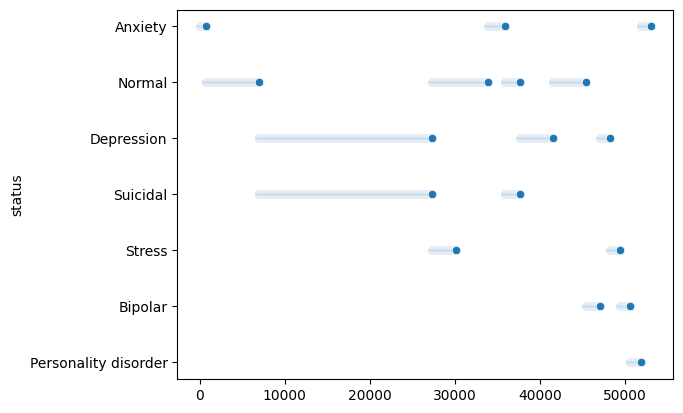

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.scatterplot(df['status'])
plt.show()

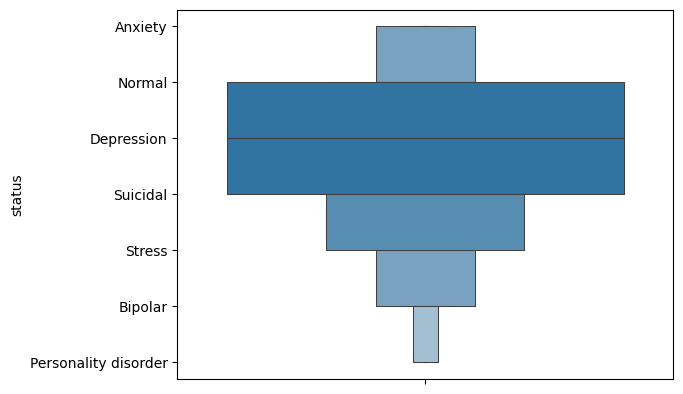

In [10]:
sns.boxenplot(df['status'])
plt.show()

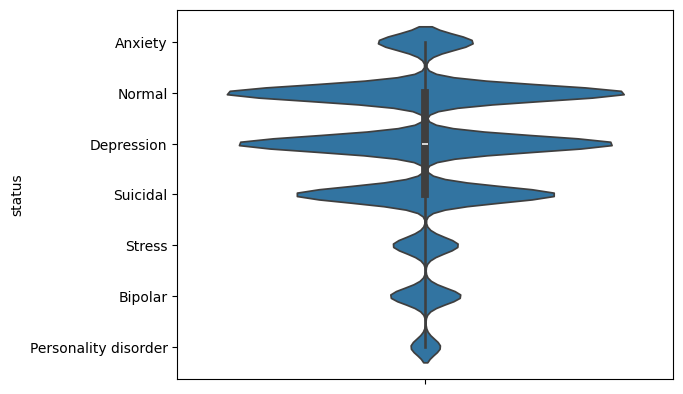

In [11]:
sns.violinplot(df['status'])
plt.show()

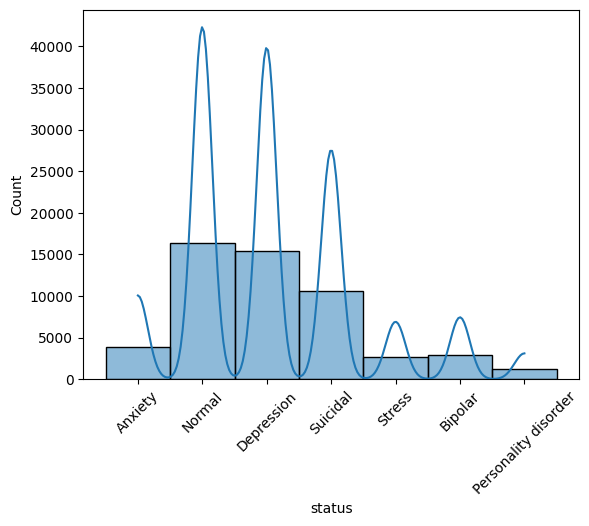

In [12]:
sns.histplot(df['status'],kde=True)
plt.xticks(rotation=45)
plt.show()

In [13]:
df.shape

(53043, 3)

In [14]:
df.isnull().sum()

Unnamed: 0      0
statement     362
status          0
dtype: int64

In [15]:
print(df[df['statement'].isnull()]['status'].value_counts())

status
Personality disorder    124
Bipolar                 100
Stress                   82
Anxiety                  47
Normal                    8
Suicidal                  1
Name: count, dtype: int64


In [16]:
null_counts=df[df['statement'].isnull()]['status'].value_counts().reset_index()
null_counts.columns=['status','null_count']

C:\Users\Atharva\AppData\Local\Temp\ipykernel_13844\112749893.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=null_counts,x='status',y='null_count',palette='Reds_r')


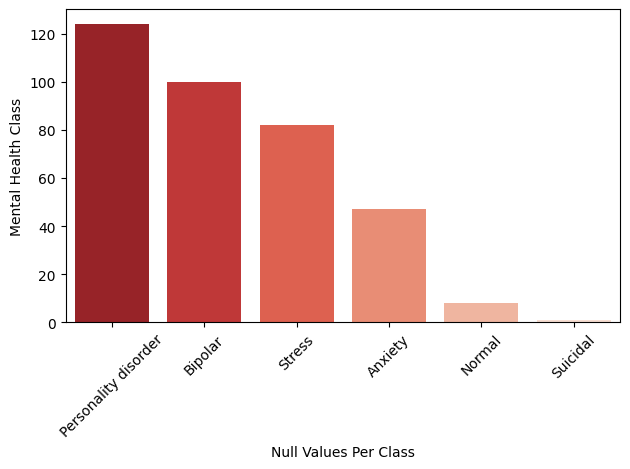

In [17]:
plt.Figure(figsize=(8,5))
sns.barplot(data=null_counts,x='status',y='null_count',palette='Reds_r')
plt.xlabel('Null Values Per Class')
plt.ylabel('Mental Health Class')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Since Total Nulls are 362 and Personality Disorder alone have 124 so we can't affor to losse some data 
## Because it is important 

In [18]:
# Now we will use smart fill--> random real sentence from same class
def smart_fill(df):
    null_idx=df[df['statement'].isnull()].index
    for idx in null_idx:
        label=df.at[idx,'status']
        pool=df[(df['status']== label) & (df['statement'].notnull())]['statement'].values
        if len(pool) > 0:
            df.at[idx,'statement'] =np.random.choice(pool)
    return df

In [19]:
df=smart_fill(df)
print(df['statement'].isnull().sum())

0


In [20]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 53043 entries, 0 to 53042
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Unnamed: 0  53043 non-null  int64
 1   statement   53043 non-null  str  
 2   status      53043 non-null  str  
dtypes: int64(1), str(2)
memory usage: 31.0 MB


In [21]:
df.isnull().sum()

Unnamed: 0    0
statement     0
status        0
dtype: int64

In [22]:
df=df.rename(columns={'statement':'text','status':'label'})


In [23]:
df=df.drop(columns=['Unnamed: 0'])

In [24]:
df

,text,label
0,oh my gosh,Anxiety
1,"trouble sleeping, confused mind, restless hear...",Anxiety
2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety
3,I've shifted my focus to something else but I'...,Anxiety
4,"I'm restless and restless, it's been a month n...",Anxiety
...,...,...
53038,Nobody takes me seriously I’ve (24M) dealt wit...,Anxiety
53039,"selfishness ""I don't feel very good, it's lik...",Anxiety
53040,Is there any way to sleep better? I can't slee...,Anxiety
53041,"Public speaking tips? Hi, all. I have to give ...",Anxiety


In [25]:
## Now cleaning the text column
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer


# Lets plot the wordcloud of all the status 

In [26]:
depression=df[df['label']=='Depression']['text'].values
text= ' '.join(depression)

In [27]:
df['label'].value_counts()

label
Normal                  16351
Depression              15404
Suicidal                10653
Anxiety                  3888
Bipolar                  2877
Stress                   2669
Personality disorder     1201
Name: count, dtype: int64

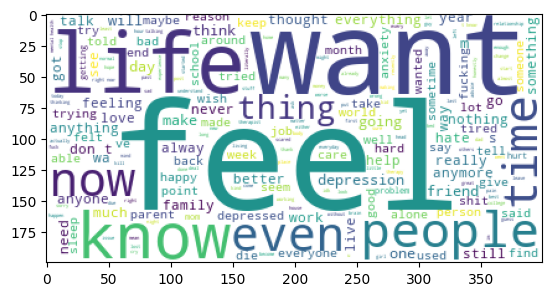

In [28]:
from wordcloud import WordCloud
wc=WordCloud(width=400,height=200,background_color='white').generate(text)
plt.Figure(figsize=(18,9))
plt.imshow(wc)

In [29]:
normal=df[df['label']=='Normal']['text'].values
text=''.join(normal)

In [30]:
print(WordCloud)

<class 'wordcloud.wordcloud.WordCloud'>


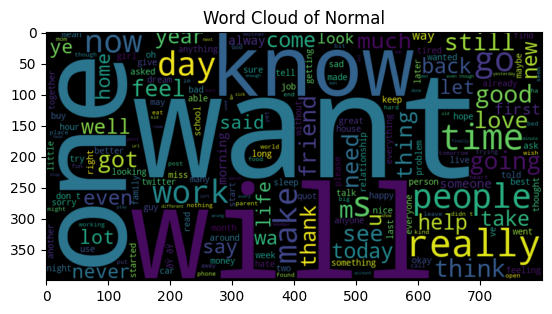

In [31]:
wc=WordCloud(width=800,height=400,background_color='black').generate(text)
plt.title('Word Cloud of Normal')
plt.imshow(wc,interpolation='bilinear')

In [32]:
sucidal=df[df['label'] == 'Suicidal']['text'].values
text=''.join(sucidal)

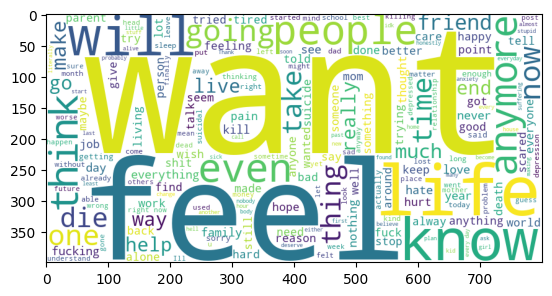

In [33]:
wc=WordCloud(width=800,height=400,background_color='white').generate(text)
plt.imshow(wc)

In [34]:
anxiety=df[df['label'] == 'Anxiety']['text'].values
text=''.join(anxiety)

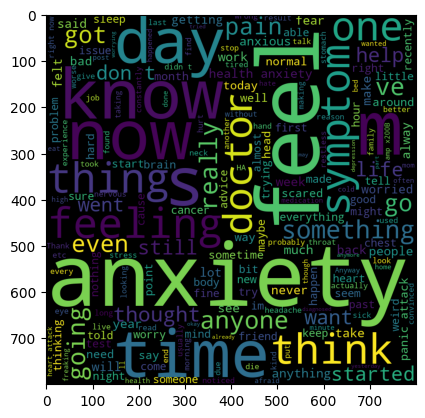

In [35]:
wc=WordCloud(width=800,height=800,background_color='black').generate(text)
plt.imshow(wc)

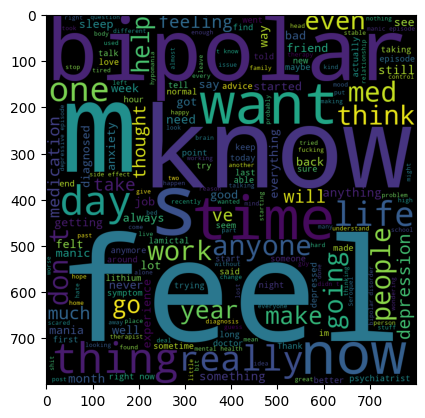

In [36]:
bipolar=df[df['label'] == 'Bipolar']['text'].values
text=''.join(bipolar)

wc=WordCloud(width=800,height=800,background_color='black').generate(text)
plt.imshow(wc)


 

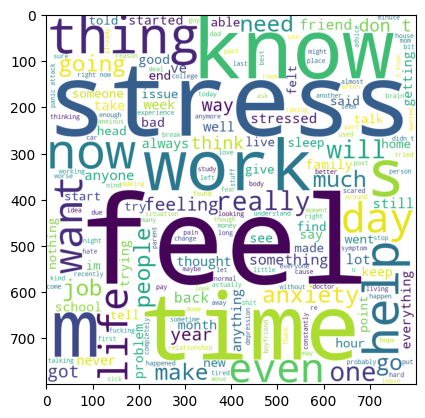

In [37]:
stress=df[df['label'] == 'Stress']['text'].values
text=''.join(stress)

wc=WordCloud(width=800,height=800,background_color='white').generate(text)
plt.imshow(wc)


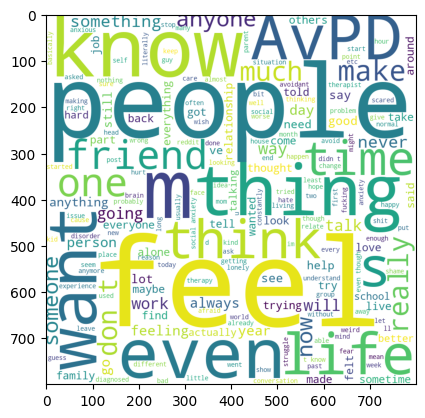

In [38]:
personality_disorder=df[df['label'] == 'Personality disorder']['text'].values
text=''.join(personality_disorder)

wc=WordCloud(width=800,height=800,background_color='white').generate(text)
plt.imshow(wc)

In [39]:
from nltk.tokenize import word_tokenize 

In [40]:
lemmatizer=WordNetLemmatizer()
stop_words=set(stopwords.words('english'))

In [41]:
## Keep negative Words because these are important for deetction
keep_words={'not','no','never','nothing','nowhere','hardly','nobody','neither','barely'}
stop_words=stop_words - keep_words

In [42]:
import re
def clean_text(text):
    text = str(text).lower()
    # remove urls
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    # remove mentions and hashtags (keeps hashtag words if you prefer remove the # only use: text = re.sub(r'#','',text))
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#\w+', '', text)
    # keep only letters and spaces
    text = re.sub(r'[^a-z\s]', ' ', text)
    # collapse multiple spaces
    text = re.sub(r'\s+', ' ', text).strip()
    # tokenize
    tokens = word_tokenize(text)
    # remove stopwords and lemmatize
    tokens = [lemmatizer.lemmatize(w) for w in tokens if w not in stop_words]
    return ' '.join(tokens)

In [43]:
df['text']=df['text'].apply(clean_text)

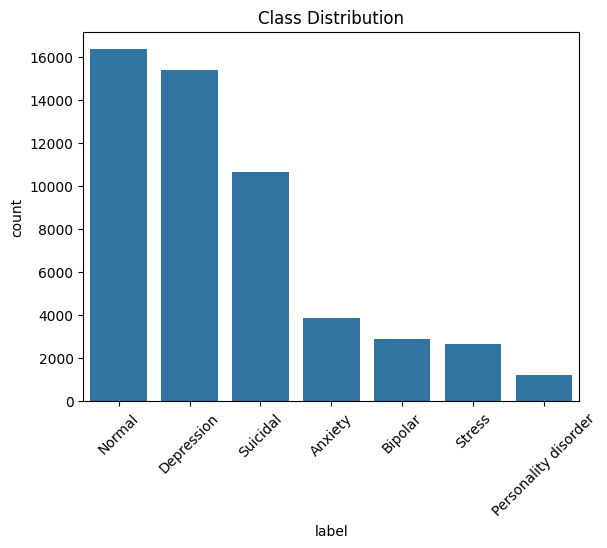

In [44]:
sns.countplot(data=df,x='label',order=df['label'].value_counts().index)
plt.title('Class Distribution')
plt.xticks(rotation=45)
plt.show()

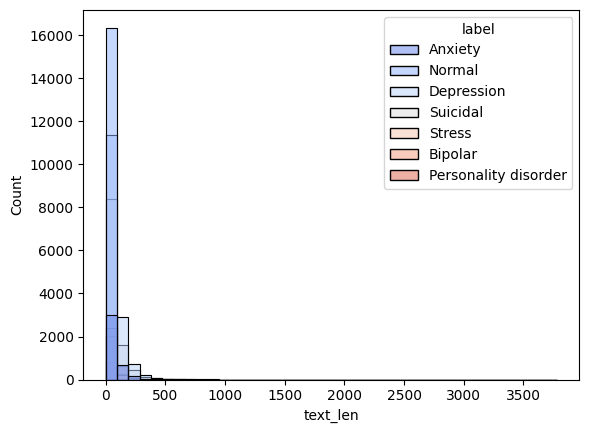

In [45]:
df['text_len']=df['text'].apply(lambda x:len(x.split()))
sns.histplot(data=df,x='text_len',hue='label',bins=40,palette='coolwarm')
plt.Figure(figsize=(16,10))
plt.show()

In [46]:
df

,text,label,text_len
0,oh gosh,Anxiety,2
1,trouble sleeping confused mind restless heart ...,Anxiety,7
2,wrong back dear forward doubt stay restless re...,Anxiety,9
3,shifted focus something else still worried,Anxiety,6
4,restless restless month boy mean,Anxiety,5
...,...,...,...
53038,nobody take seriously dealt depression anxiety...,Anxiety,163
53039,selfishness feel good like belong world think ...,Anxiety,89
53040,way sleep better sleep night med help,Anxiety,7
53041,public speaking tip hi give presentation work ...,Anxiety,35


## Now all the thigs related to EDA And feature engineering is done!

## And cleaning is Done we will move to model building

In [47]:
import pickle
pickle.dump(df,open('cleaned_df.pkl','wb'))